In [10]:
from data_loader import load_all_datasets
datasets = load_all_datasets()


mMTC: detected separator=','
Loaded mMTC: (4615, 52)
URLLC: detected separator=','
Loaded URLLC: (4033, 52)
eMBB: detected separator=','
Loaded eMBB: (5808, 52)
TON_IoT: detected separator=';'
Loaded TON_IoT: (210969, 45)

Loaded 4 datasets: ['mMTC', 'URLLC', 'eMBB', 'TON_IoT']


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📌 Basic Dataset Overview
### 3. Dataset Overview
Structural summary of each dataset: shape, label distribution, data types.


## 🔍 Cell Description — Dataset Overview Function

This cell defines `dataset_overview()` and runs it on every loaded dataset to produce a quick structural summary.

**What it computes and displays per dataset:**
- **Shape** — number of rows and columns (e.g., `(50000, 15)`)
- **Dtypes** — count of numeric vs object columns (helps spot unexpected string columns)
- **Label distribution** — how many Benign vs Malicious samples exist
- **Imbalance ratio** — `max_class_count / min_class_count`; a ratio above 2.0 triggers SMOTE later
- **Two side-by-side horizontal bar charts:**
  - Left: label counts (green = Benign, red = Malicious)
  - Right: data type breakdown (blue)

**Why this matters:** Understanding imbalance early is critical. If 95% of samples are Benign and only 5% Malicious, a naive model can achieve 95% accuracy by always predicting Benign — but it would be useless as an IDS. This overview sets the expectation for where SMOTE will be needed.


=== mMTC ===
  Shape  : (4615, 52)
  Dtypes : {dtype('float64'): np.int64(38), dtype('O'): np.int64(7), dtype('int64'): np.int64(7)}
  Labels : {'Benign': np.int64(2462), 'Malicious': np.int64(2153)}
  Imbalance ratio: 1.14:1


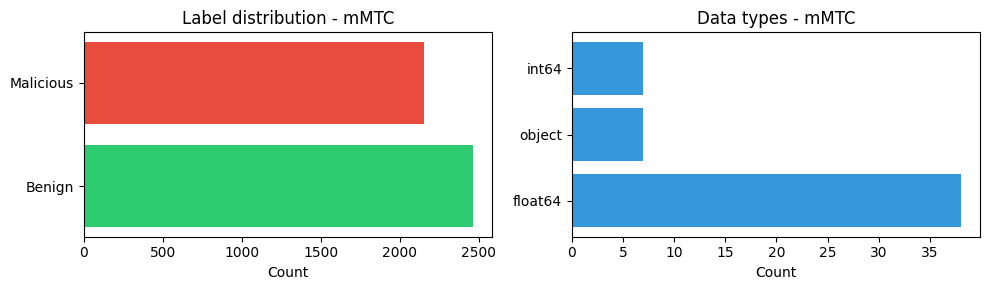


=== URLLC ===
  Shape  : (4033, 52)
  Dtypes : {dtype('float64'): np.int64(32), dtype('int64'): np.int64(13), dtype('O'): np.int64(7)}
  Labels : {'Malicious': np.int64(2461), 'Benign': np.int64(1572)}
  Imbalance ratio: 1.57:1


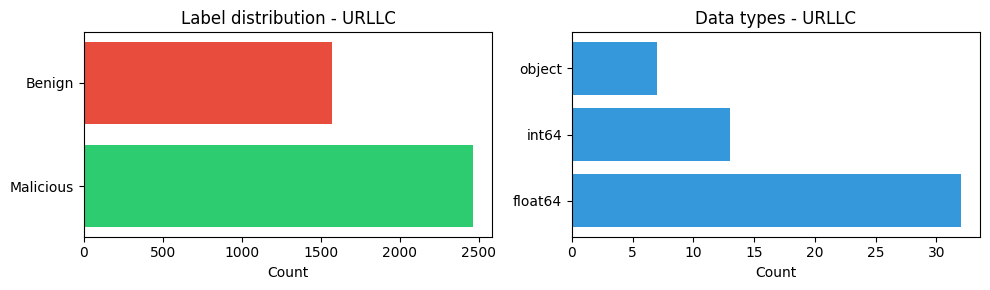


=== eMBB ===
  Shape  : (5808, 52)
  Dtypes : {dtype('float64'): np.int64(33), dtype('int64'): np.int64(12), dtype('O'): np.int64(7)}
  Labels : {'Benign': np.int64(3023), 'Malicious': np.int64(2785)}
  Imbalance ratio: 1.09:1


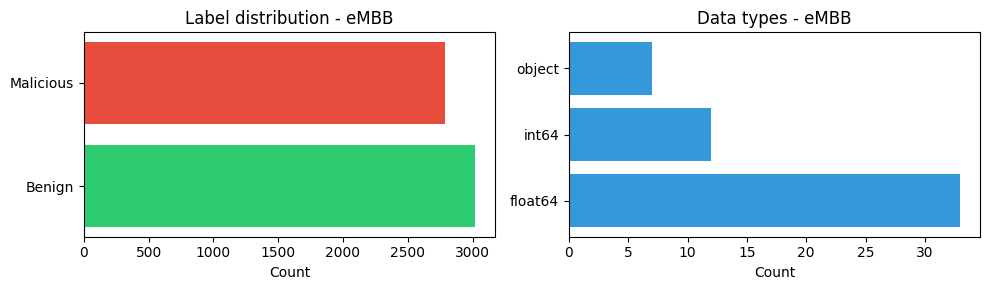


=== TON_IoT ===
  Shape  : (210969, 45)
  Dtypes : {dtype('O'): np.int64(28), dtype('float64'): np.int64(15), dtype('int64'): np.int64(2)}
  Labels : {'Malicious': np.int64(160986), 'Benign': np.int64(49983)}
  Imbalance ratio: 3.22:1


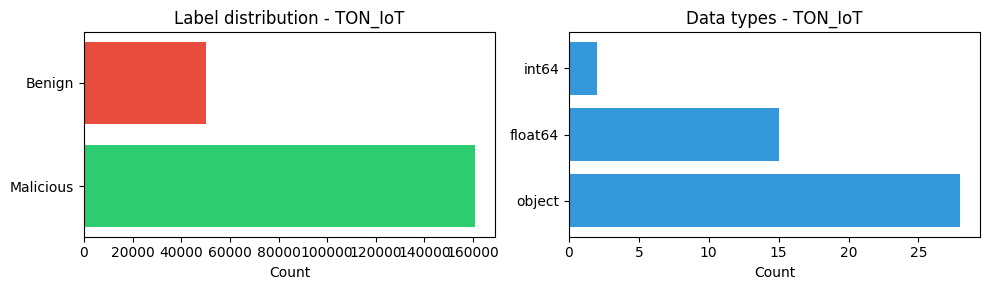

In [12]:
def dataset_overview(df, name, label_col='Label'):
    print(f'\n=== {name} ===')
    if label_col not in df.columns:
        print(f'  Warning: label column not found. Columns: {list(df.columns)}')
        return
    print(f'  Shape  : {df.shape}')
    print(f'  Dtypes : {dict(df.dtypes.value_counts())}')
    vc = df[label_col].value_counts(dropna=False)
    print(f'  Labels : {dict(vc)}')
    ratio = vc.max() / vc.min()
    print(f'  Imbalance ratio: {ratio:.2f}:1')

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].barh(vc.index.astype(str), vc.values, color=['#2ecc71','#e74c3c'])
    axes[0].set_title(f'Label distribution - {name}')
    axes[0].set_xlabel('Count')
    dtype_counts = df.dtypes.value_counts()
    axes[1].barh(dtype_counts.index.astype(str), dtype_counts.values, color='#3498db')
    axes[1].set_title(f'Data types - {name}')
    axes[1].set_xlabel('Count')
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    dataset_overview(d, n)


## 📌 Data Quality Report
### 4. Data Quality Assessment
Evaluates: missing values, duplicate rows, outlier percentage.


## 🔍 Cell Description — Data Quality Assessment

This cell defines `quality_report_graph()` and evaluates three data quality metrics for each dataset, displayed as a bar chart.

**Metric 1 — Missing values %:**
- Counts all NaN cells across the entire DataFrame.
- Formula: `(total NaN cells) / (rows × columns) × 100`
- High missing % would require imputation strategy decisions.

**Metric 2 — Duplicate rows %:**
- Counts rows that are exact duplicates of a prior row.
- Formula: `duplicate_count / total_rows × 100`
- High duplicates would inflate model performance artificially.

**Metric 3 — Outlier %:**
- Uses the **IQR method** for every numeric column:
  - Compute Q1 (25th percentile) and Q3 (75th percentile)
  - IQR = Q3 − Q1
  - Any value below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` is flagged as an outlier
- Formula: `total outlier cells / (rows × numeric_columns) × 100`
- High outlier % motivates using `RobustScaler` (which is median-based and less sensitive to extremes) rather than `StandardScaler` in the preprocessing pipeline.

**Visual output:** A color-coded bar chart per dataset (red = missing, blue = duplicates, orange = outliers).

mMTC — Missing: 5.58% | Duplicates: 0.00% | Outliers: 8.88%


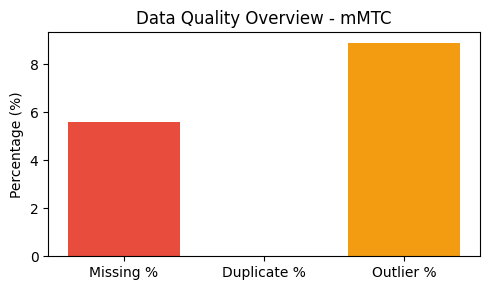

URLLC — Missing: 17.38% | Duplicates: 0.00% | Outliers: 6.77%


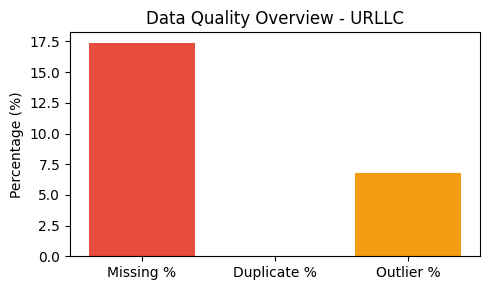

eMBB — Missing: 3.85% | Duplicates: 0.00% | Outliers: 4.62%


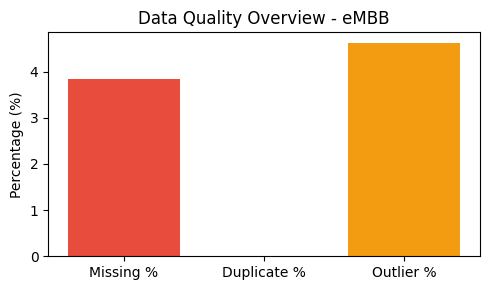

TON_IoT — Missing: 0.00% | Duplicates: 9.75% | Outliers: 11.69%


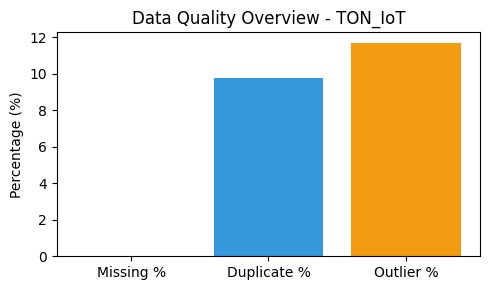

In [13]:
def quality_report_graph(df, name):
    total_rows = len(df)
    missing_pct   = (df.isna().sum().sum() / (df.shape[0] * df.shape[1])) * 100
    duplicate_pct = (df.duplicated().sum() / total_rows) * 100
    num_cols = df.select_dtypes(include=np.number).columns
    outlier_total = 0
    for col in num_cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_total += ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_pct = (outlier_total / (total_rows * max(len(num_cols),1))) * 100
    print(f'{name} — Missing: {missing_pct:.2f}% | Duplicates: {duplicate_pct:.2f}% | Outliers: {outlier_pct:.2f}%')
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(['Missing %','Duplicate %','Outlier %'],
           [missing_pct, duplicate_pct, outlier_pct],
           color=['#e74c3c','#3498db','#f39c12'])
    ax.set_title(f'Data Quality Overview - {name}')
    ax.set_ylabel('Percentage (%)')
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    quality_report_graph(d, n)


## 📌 Exploratory Data Analysis (EDA)
### 5.1 Class Distribution


## 🔍 Cell Description — EDA: Class Distribution Bar Charts

This cell defines `plot_class_distribution()` and calls it once per dataset. It plots a **simple vertical bar chart** showing the raw count of each class label (`Benign` vs `Malicious`).

**Why this is different from Cell 7's overview:** Cell 7 shows the imbalance ratio as a number. This cell makes it *visually obvious* — a very tall green bar next to a short red bar immediately communicates that the dataset is heavily skewed toward Benign traffic, which is realistic in network data.

**Design choice:** Green (`#2ecc71`) for Benign, red (`#e74c3c`) for Malicious — consistent color coding used throughout the notebook.

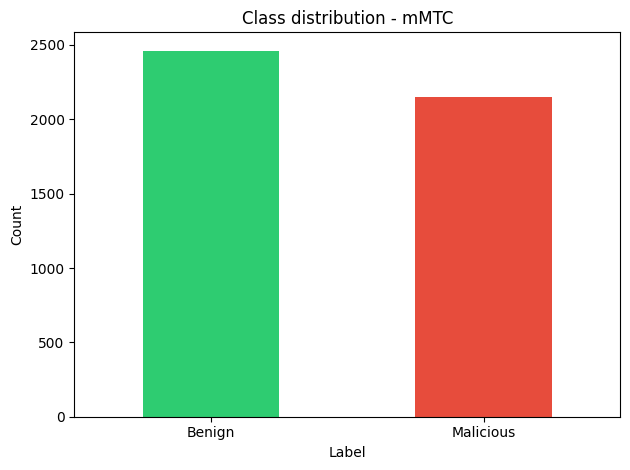

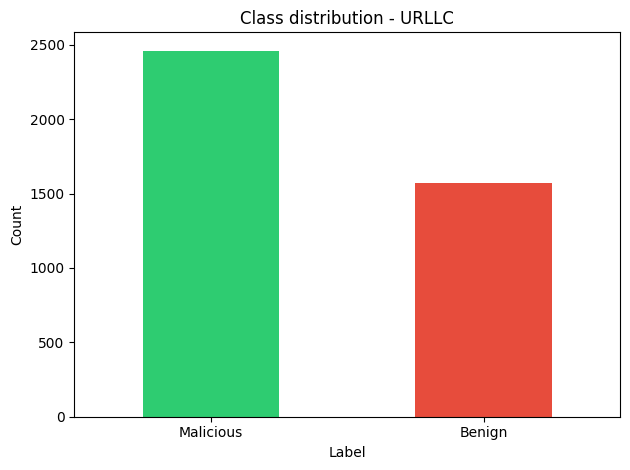

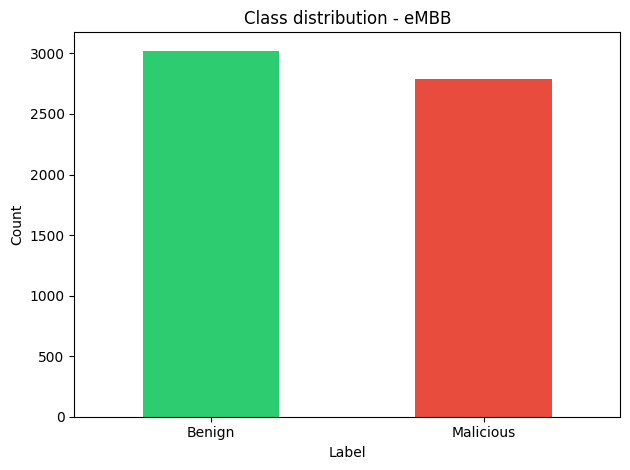

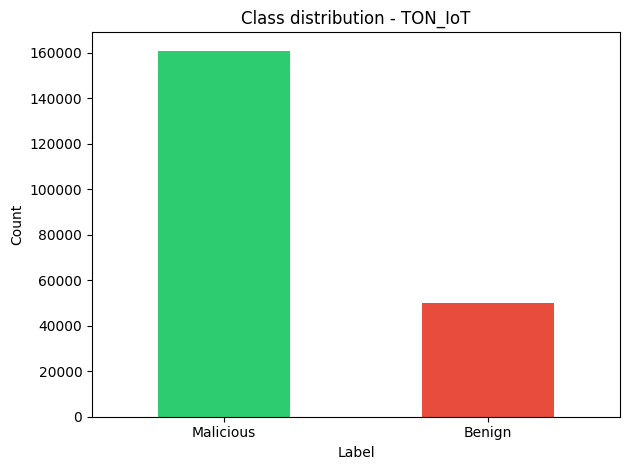

In [14]:
def plot_class_distribution(df, name, label_col='Label'):
    if label_col not in df.columns:
        print(f'Column not found in {name}')
        return
    vc = df[label_col].value_counts()
    ax = vc.plot(kind='bar', color=['#2ecc71','#e74c3c'])
    ax.set_title(f'Class distribution - {name}')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    plot_class_distribution(d, n)


## 5.2 Attack Type Breakdown
Shows attack subtypes per dataset. Used for understanding only — `type` column is excluded from features.


## 🔍 Cell Description — EDA: Attack Type Breakdown (Subtypes)

This cell maps each dataset to its attack subtype column (`type`) and plots a breakdown of attack categories within malicious traffic.

**Key design decision — `TYPE_COL` dictionary:**
- `mMTC`, `URLLC`, `eMBB` → `None` — these 5G slice datasets only have a binary `Label` column; no attack subtype information is available.
- `TON_IoT` → `'type'` — this dataset includes a `type` column with 9 named attack categories (e.g., DDoS, Ransomware, Backdoor, Scanning, etc.).

**Important note:** The `type` column is intentionally **excluded from model features** (it is dropped in `make_xy()` in Cell 19). It is used here for *understanding only* — to know what kinds of attacks we are dealing with. Using it as a feature would be data leakage (the model would be predicting attack type using attack type).

**Output:** For TON_IoT, a rotated bar chart shows each of the 9 attack subtypes and their frequency. For the other three datasets, a message confirms no subtype column exists.

mMTC — no attack subtype column (binary label only)
URLLC — no attack subtype column (binary label only)
eMBB — no attack subtype column (binary label only)

TON_IoT — Attack type breakdown:
type
normal        49983
dos           20000
scanning      20000
ransomware    20000
injection     19998
xss           19995
ddos          19986
backdoor      19982
password      19982
mitm           1043


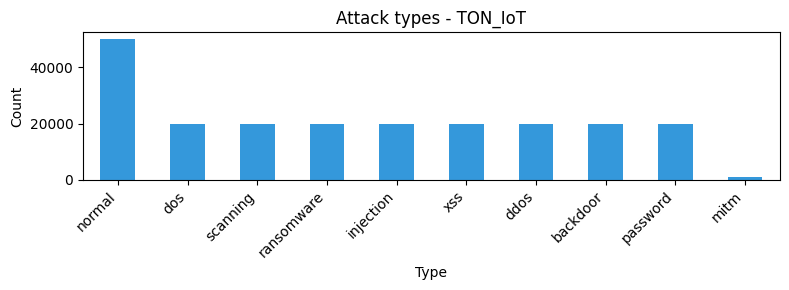

In [15]:
# Attack subtype column varies per dataset
TYPE_COL = {
    'mMTC':    None,  # no subtype column in slice datasets
    'URLLC':   None,
    'eMBB':    None,
    'TON_IoT': 'type',
}

for n, d in datasets.items():
    col = TYPE_COL.get(n)
    if col and col in d.columns:
        print(f'\n{n} — Attack type breakdown:')
        tc = d[col].value_counts()
        print(tc.to_string())
        fig, ax = plt.subplots(figsize=(8, 3))
        tc.plot(kind='bar', ax=ax, color='#3498db')
        ax.set_title(f'Attack types - {n}')
        ax.set_xlabel('Type')
        ax.set_ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f'{n} — no attack subtype column (binary label only)')


## 5.3 Numeric Feature Distribution Analysis


## 🔍 Cell Description — EDA: Numeric Feature Histograms

This cell defines `plot_numeric_hists()` and generates **histogram grids** for the first 8 numeric features of each dataset.

**What it does:**
- Selects all numeric columns (float64, int64), excluding `UniqueID`, `X`, and `label_raw` (index/metadata columns with no predictive value).
- Limits to 8 columns maximum to keep the plot readable.
- Plots a 30-bin histogram grid using pandas' `.hist()`.

**Why histograms matter here:** Network traffic features are typically **heavily right-skewed** — most connections are short and low-volume, but a few are extremely large (DDoS attacks, large file transfers). Seeing this skew visually justifies the `log1p` transformation applied in the preprocessing pipeline (Cell 19), which compresses large values and makes the distribution more symmetric for ML models.

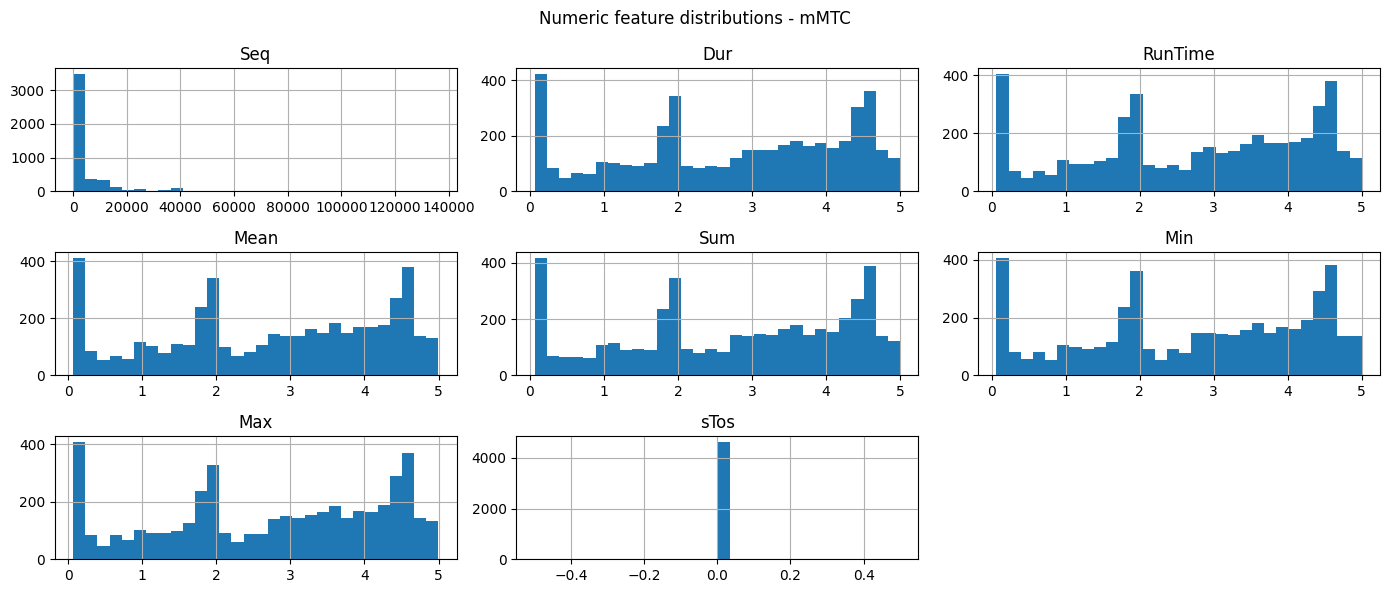

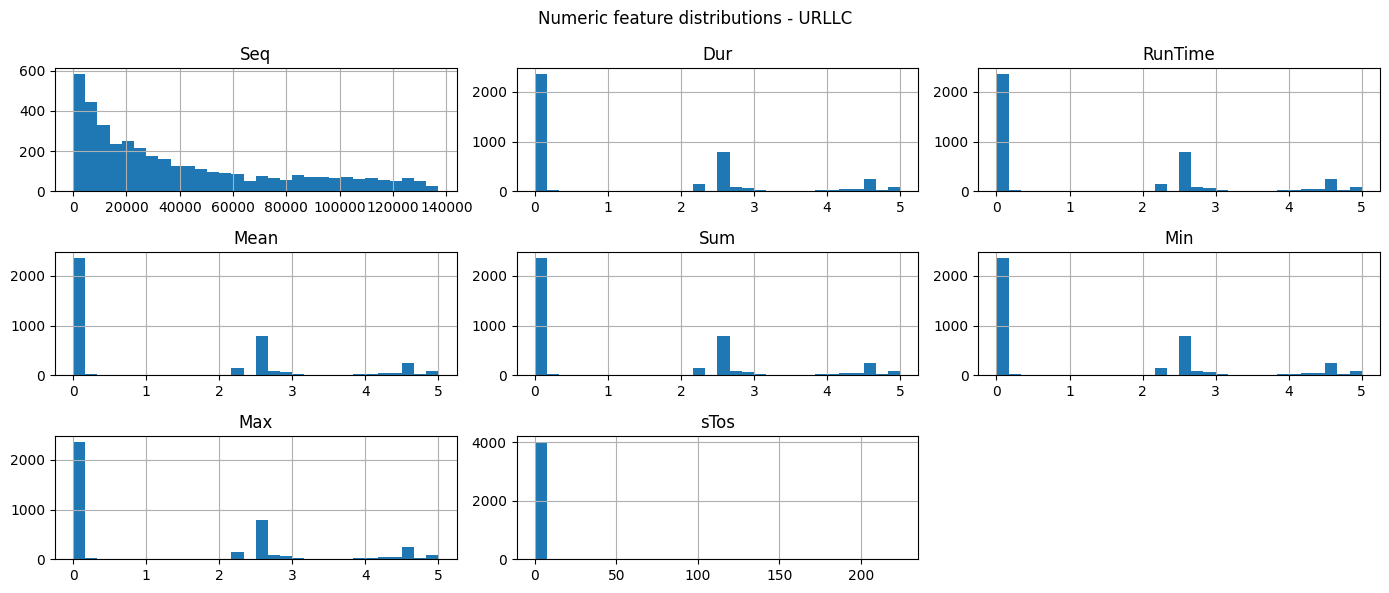

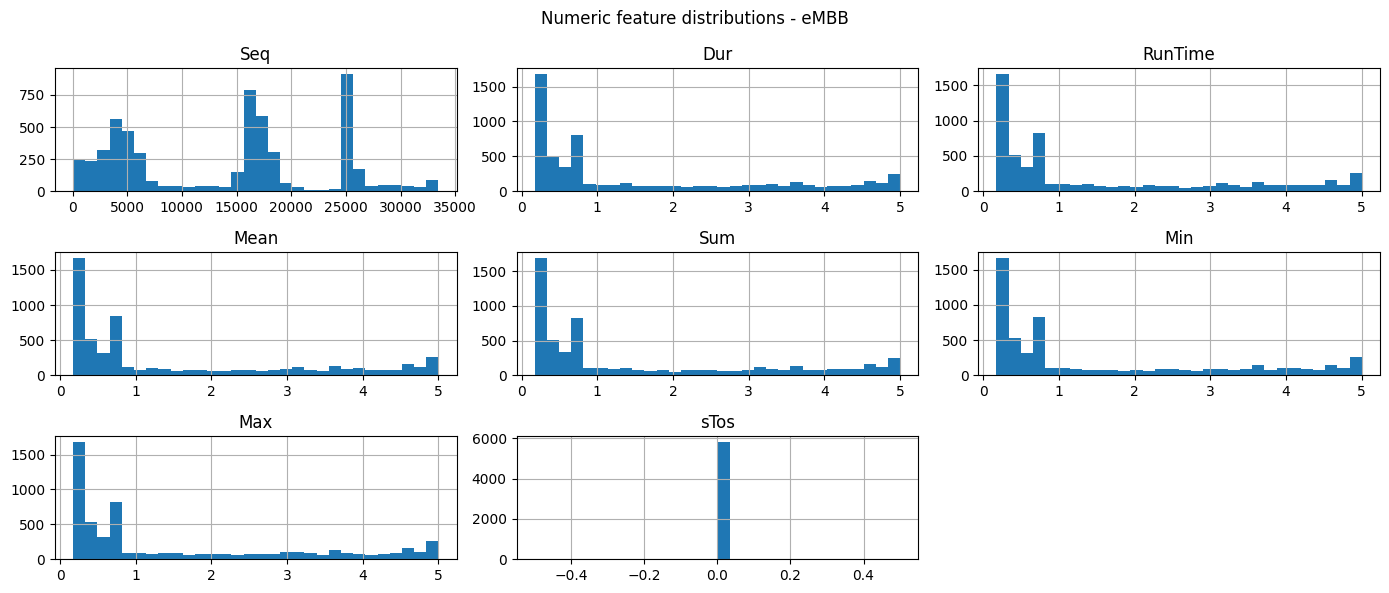

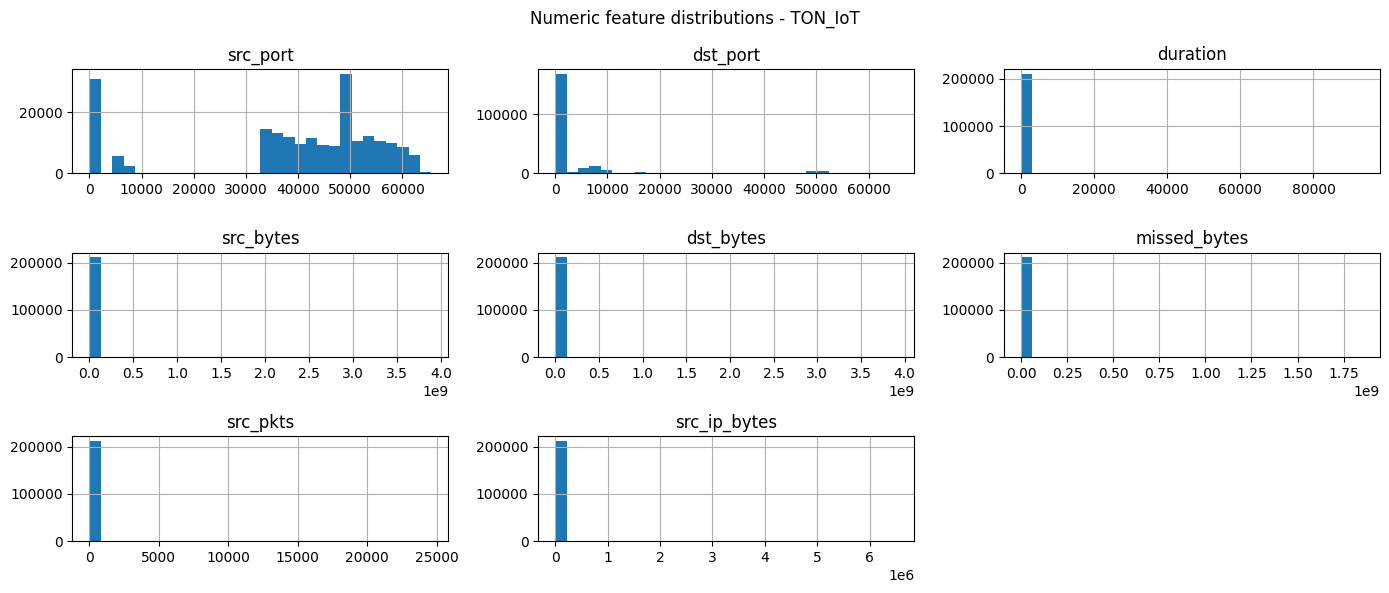

In [16]:
def plot_numeric_hists(df, name, n_cols=8):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude  = ['UniqueID','X','label_raw']
    num_cols = [c for c in num_cols if c not in exclude][:n_cols]
    if not num_cols:
        print(f'No numeric columns for {name}')
        return
    df[num_cols].hist(bins=30, figsize=(14, 6))
    plt.suptitle(f'Numeric feature distributions - {name}')
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    plot_numeric_hists(d, n)


## 5.4 Correlation Analysis


## 🔍 Cell Description — EDA: Correlation Matrix Heatmap

This cell defines `plot_correlation_matrix()` and plots a **Pearson correlation heatmap** for all numeric features in each dataset.

**What it does:**
- Selects all numeric columns, excluding metadata columns (`UniqueID`, `X`, `label_raw`).
- Computes pairwise Pearson correlation coefficients (values range from −1 to +1).
- Displays as a `seaborn` heatmap with a `coolwarm` colormap (blue = negative correlation, red = positive, white = near zero).

**How to read the heatmap:**
- **Dark red cells** (correlation ≈ +1): two features are nearly redundant (e.g., `TotBytes` and `Load` often correlate strongly in network data).
- **Dark blue cells** (correlation ≈ −1): features move in opposite directions.
- **White/neutral cells**: features are independent — both are informative.

**Why this matters:** Highly correlated features add redundancy. The feature selection in Cells 21–24 was partly guided by these correlations — choosing a subset that retains variety rather than repeating the same signal in multiple columns.

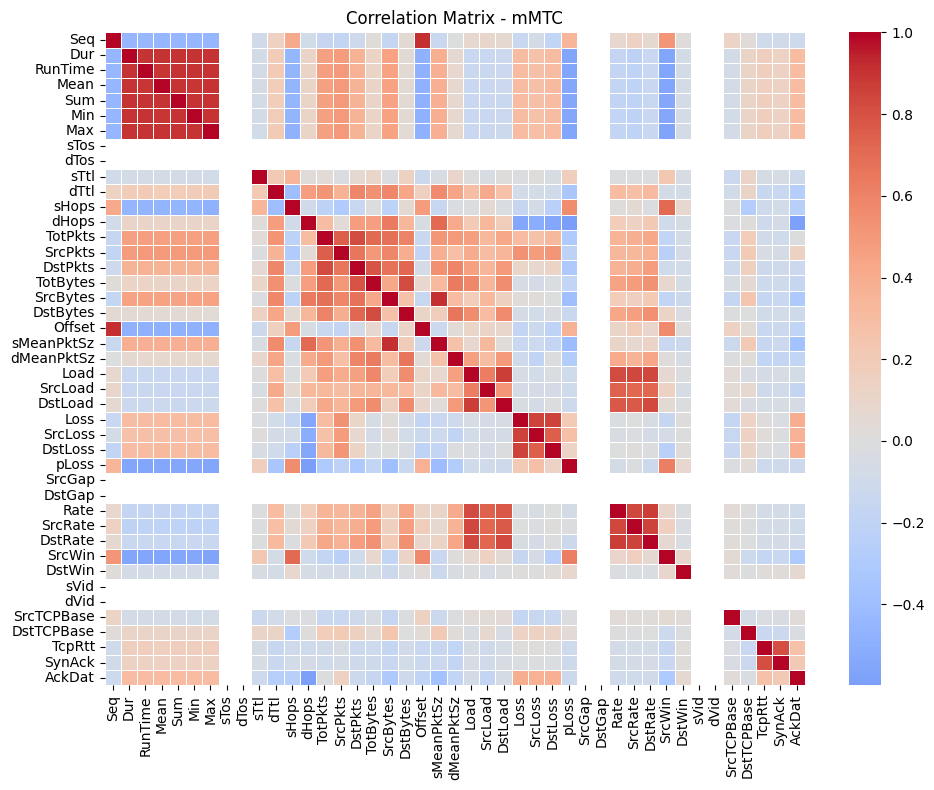

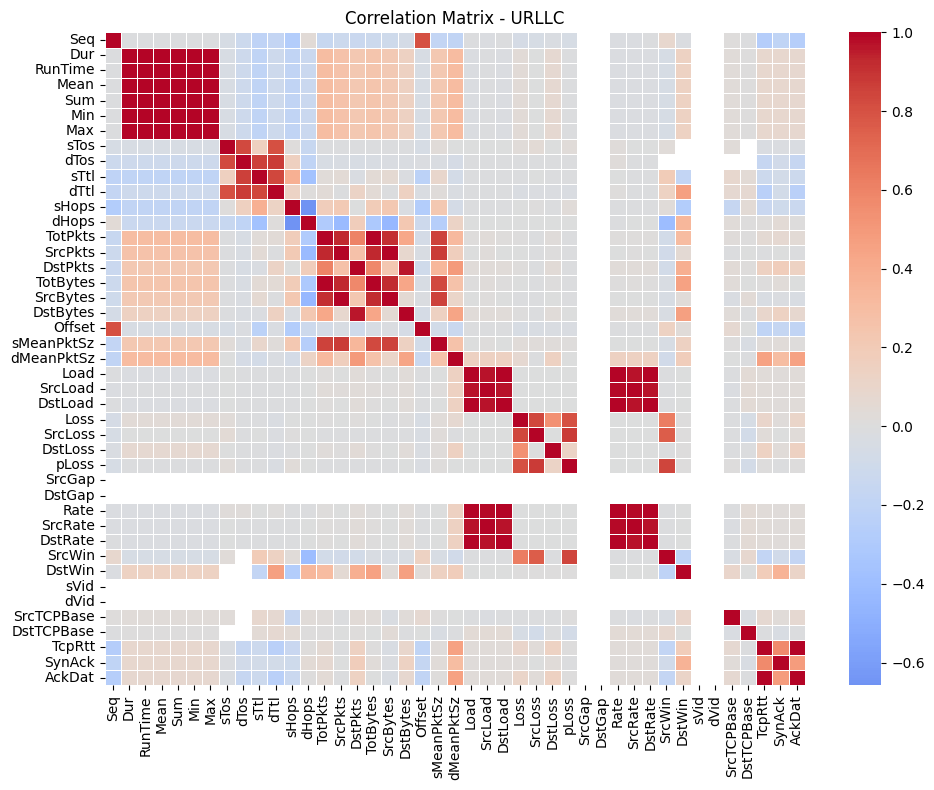

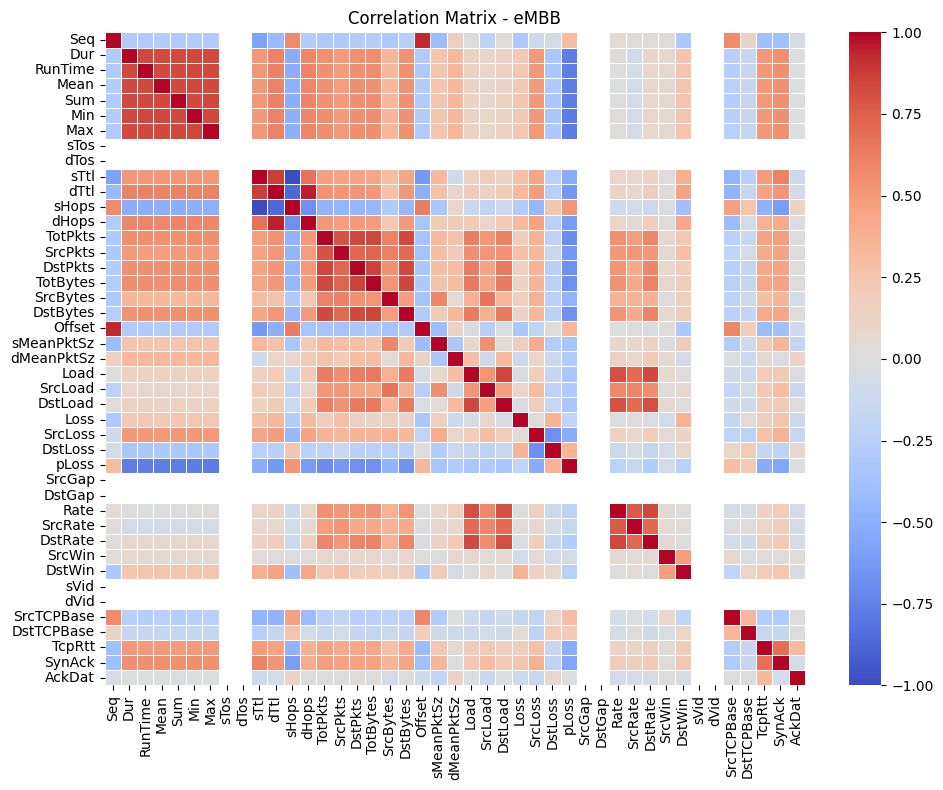

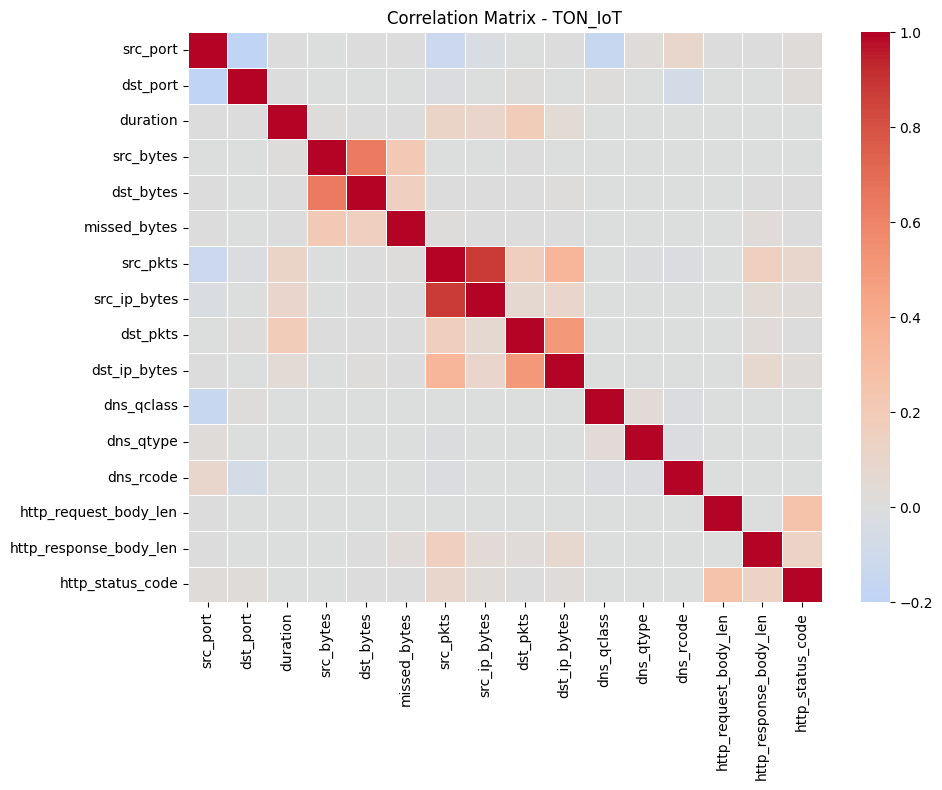

In [17]:
def plot_correlation_matrix(df, name):
    num = df.select_dtypes(include=[np.number]).copy()
    exclude = ['UniqueID','X','label_raw']
    num = num.drop(columns=[c for c in exclude if c in num.columns])
    if num.shape[1] < 2:
        print(f'Not enough numeric columns in {name}')
        return
    corr = num.corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
    plt.title(f'Correlation Matrix - {name}')
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    plot_correlation_matrix(d, n)
